In [1]:
#this code with reload any imports if you're updating them actively
%reload_ext autoreload
%autoreload 2
#import scipy.obinimize as obin
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
#PyGEM
import pygem_eb.input as eb_prms
import pygem.pygem_input as pygem_prms
import pygem.pygem_modelsetup as modelsetup
import class_climate

In [2]:
if pygem_prms.glac_no not in ['01.00570'] and pygem_prms.run_eb:
    print('EB model can currently only run Gulkana glacier')
glacier_table = modelsetup.selectglaciersrgitable(pygem_prms.glac_no,
                rgi_regionsO1=pygem_prms.rgi_regionsO1, rgi_regionsO2=pygem_prms.rgi_regionsO2,
                rgi_glac_number=pygem_prms.rgi_glac_number, include_landterm=pygem_prms.include_landterm,
                include_laketerm=pygem_prms.include_laketerm, include_tidewater=pygem_prms.include_tidewater)
# Automatically generate hourly (freq = 'h') dates
startdate = eb_prms.startdate
enddate = eb_prms.enddate
dates_table = pd.DataFrame({'date' : pd.date_range(startdate, enddate, freq='h')})
# Extract attributes for dates_table
dates_table['year'] = dates_table['date'].dt.year
dates_table['month'] = dates_table['date'].dt.month
dates_table['day'] = dates_table['date'].dt.day
dates_table['hour'] = dates_table['date'].dt.hour
dates_table['daysinmonth'] = dates_table['date'].dt.daysinmonth
dates_table['timestep'] = np.arange(len(dates_table['date']))
# Set date as index
dates_table.set_index('timestep', inplace=True)
# Remove leap year days if user selected this with option_leapyear
if pygem_prms.option_leapyear == 0:
    # First, change 'daysinmonth' number
    mask1 = dates_table['daysinmonth'] == 29
    dates_table.loc[mask1,'daysinmonth'] = 28
    # Next, remove the 29th days from the dates
    mask2 = ((dates_table['month'] == 2) & (dates_table['day'] == 29))
    dates_table.drop(dates_table[mask2].index, inplace=True)
    dates_table['timestep'] = np.arange(len(dates_table['date']))
    dates_table.set_index('timestep', inplace=True)

# Add column for water year
# Water year for northern hemisphere using USGS definition (October 1 - September 30th),
# e.g., water year for 2000 is from October 1, 1999 - September 30, 2000
dates_table['wateryear'] = dates_table['year']
for step in range(dates_table.shape[0]):
    if dates_table.loc[step,'month'] >= 10:
        dates_table.loc[step,'wateryear'] = dates_table.loc[step,'year'] + 1

EB model can currently only run Gulkana glacier
1 glaciers in region 1 are included in this model run: ['00570']
This study is focusing on 1 glaciers in region [1]


In [3]:
gcm = class_climate.GCM(name='ERA5-hourly')
gcm_prec, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.prec_fn, gcm.prec_vn, glacier_table,dates_table)
gcm_temp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.temp_fn, gcm.temp_vn, glacier_table,dates_table)
gcm_dtemp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.dtemp_fn, gcm.dtemp_vn, glacier_table,dates_table)
gcm_sp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.press_fn, gcm.press_vn, glacier_table,dates_table)
gcm_tcc, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.tcc_fn, gcm.tcc_vn, glacier_table,dates_table)
gcm_surfrad, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.surfrad_fn, gcm.surfrad_vn, glacier_table,dates_table) 
gcm_uwind, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.uwind_fn, gcm.uwind_vn, glacier_table,dates_table)                                                      
gcm_vwind, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.vwind_fn, gcm.vwind_vn, glacier_table,dates_table)

gcm_elev = gcm.importGCMfxnearestneighbor_xarray(gcm.elev_fn, gcm.elev_vn, glacier_table)

!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables


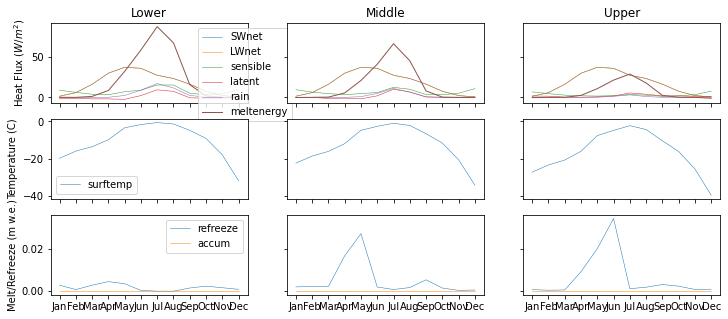

In [56]:
#ds = xr.open_dataset('/home/claire/research/Output/EB/run_2023_06_07_hourly_3yrs.nc')
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plotidx = len(months)

fig,axes = plt.subplots(3,3,sharex=True,sharey='row',figsize=(12,5))
nyr = 2

ds = xr.open_dataset('/home/claire/research/Output/EB/run_2023_06_15_hourly_08.nc')
varnames_idx = ['SWin','SWout','LWin','LWout','sensible','latent','rain','meltenergy','surftemp','melt','runoff','refreeze','accum']
varnames = ['SWnet','LWnet','sensible','latent','rain','meltenergy','surftemp','refreeze','accum']
heat = ['SWnet','LWnet','sensible','latent','rain','meltenergy']
temp = ['surftemp']
mb = ['melt','runoff','refreeze','accum']

for bin_no in [0,1,2]:
    df = ds[varnames_idx].isel(bin=bin_no).to_pandas()
    df['SWnet'] = df['SWin'] + df['SWout']
    df['LWnet'] = df['SWin'] + df['SWout']
    
    for var in varnames:
        if var in ['melt','runoff','refreeze','MB']:
            monthly = df[var].resample('M').sum()
        else:
            monthly = df[var].resample('M').mean()
        monthly_avg = np.mean(monthly[:(nyr*12)].values.reshape((nyr,12)),axis=0)

        axis = np.piecewise(var,[var in heat, var in temp, var in mb],[0,1,2])
        lw = 1 if var in ['meltenergy'] else 0.5
        axes[int(axis),bin_no].plot(months,monthly_avg[:plotidx],label=var,linewidth=lw)
axes[0,0].set_ylabel('Heat Flux ($W / m^2$)')
axes[1,0].set_ylabel('Temperature (C)')
axes[2,0].set_ylabel('Melt/Refreeze (m w.e.)')

binname = ['Lower','Middle','Upper']
for i in range(3):
    axes[0,i].set_title(binname[i])
axes[0,0].legend(loc='upper right',bbox_to_anchor=(1.25, 1.0))
axes[1,0].legend()
axes[2,0].legend()
#plt.gcf().autofmt_xdate()
plt.show()


C


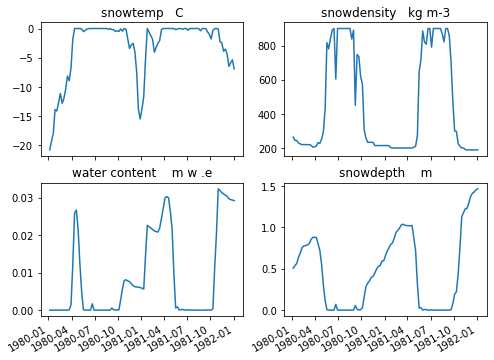

In [54]:
freq = 'W'
print(ds['snowtemp'].attrs['units'])
bin = 0
fig,axes = plt.subplots(2,2,sharex=True,figsize=(8,6)) #,sharex=True,sharey='row',figsize=(12,5)
idxs = [[0,0],[0,1],[1,0],[1,1]]
for ax,var in enumerate(['snowtemp','snowdensity','watercont','layerheight']):
    snow = ds[var].sel(bin=bin).to_pandas()
    loop = True
    i=19
    while loop:
        if np.isnan(snow.iloc[i]).all:
            snow.drop(i,axis=1)
        i -=1
        if i == 0:
            break

    time = ds.coords['time'].values
    endtime = time[-1] +pd.Timedelta(days=5)
    time = pd.date_range(time[0],endtime,freq=freq)

    if var in ['snowtemp','snowdensity']:
        snow = snow.mean(axis=1)
    else:
        snow = snow.iloc[:,:-1].sum(axis=1)
    if var in ['watercont']:
        snow = snow/1000 # to m w.e.
    snowdaily = snow.resample(freq).mean()

    idx = idxs[ax]
    axes[idx[0],idx[1]].plot(time,snowdaily,label=var)
    axes[idx[0],idx[1]].set_title(var+'   '+ds[var].attrs['units'])
axes[1,1].set_title('snowdepth    m')
axes[1,0].set_title('water content    m w .e')
plt.gcf().autofmt_xdate()
plt.savefig('/home/claire/research/Output/EB/subsurfplot.png')
plt.show()

In [18]:
array = np.array([2,3,4,5,6])
color = ['r','g','b','b','b']
for i,a in enumerate(array):
    print(i,a)
    print(color[i])

0 2
r
1 3
g
2 4
b
3 5
b
4 6
b


In [105]:
zero = np.zeros(8760)
name = '/home/claire/research/Output/EB/run_2023_06_06_hourly_00.nc'
with xr.open_dataset(name) as data:
    ds = data.load()
    ds['snowtemp'].loc[:,0] = zero
ds.to_netcdf(name)

In [107]:
import xarray as xr
ds = xr.open_dataset('/home/claire/research/climate_data/ERA5/ERA5_hourly/ERA5_precip_hourly.nc')
print(np.mean(ds['tp'].values),np.max(ds['tp'].values))
print(np.sum(ds['tp'].values[:8790]))

9.609282174515584e-05 0.004886787384748459


In [ ]:
ds = xr.open_dataset('/home/claire/research/Output/EB/run_2023_06_06_hourly_00.nc')
fig,(ax1,ax2) = plt.subplots(2,1)
end = 7000
time = ds.coords['time'][start:end]
# ax1.plot(time,ds['SWin'][start:end],label='SWin')
# ax1.plot(time,ds['SWout'][start:end],label='SWout')
ax1.plot(time,ds['SWout'][start:end]+ds['SWin'][start:end],label='Snet')
ax1.plot(time,ds['LWin'][start:end],label='LWin')
ax1.plot(time,ds['LWout'][start:end],label='LWout')
ax1.plot(time,ds['rain'][start:end],label='rain')
ax1.plot(time,ds['sensible'][start:end],label='sensible')
ax1.plot(time,ds['latent'][start:end],label='latent')
ax1.plot(time,ds['meltenergy'][start:end],label='melt E')
ax2.plot(time,ds['surftemp'][start:end],label='surftemp')
plt.gcf().autofmt_xdate()
ax1.legend()
plt.show()